<a href="https://www.kaggle.com/code/mumerfarooqbajwa/logistic-regression?scriptVersionId=342690288" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/martaarroyo/palmer-penguins-for-binary-classification/penguins_binary_classification.csv


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("martaarroyo/palmer-penguins-for-binary-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/martaarroyo/palmer-penguins-for-binary-classification


# **Logistic Regression Implementation (Perceptron Trick)**

In [3]:
def perceptron_trick (X, y, lr=.25, epochs = 3500):

    X= np.insert(X, 0, 1, axis=1)
    weights = [1 for i in range(X.shape[1])]

    for i in range(epochs):
        j = np.random.randint(0, X.shape[0])
        y_hat = int(np.dot(X[j], weights) > 0)
        #print(y_hat, " ::: ", y[j], " ::: ", weights, " ::: ", end="")
        weights = weights + lr *(y[j]-y_hat)*X[j]
        #print(weights, " ::: ",lr *(y[j]-y_hat)*X[j])


    return weights [0],  weights [1:]

In [4]:
df = pd.read_csv("/kaggle/input/datasets/martaarroyo/palmer-penguins-for-binary-classification/penguins_binary_classification.csv")


In [5]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007
...,...,...,...,...,...,...,...
269,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,2009
270,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,2009
271,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,2009
272,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,2009


In [6]:
df['year'].unique()

array([2007, 2008, 2009])

In [7]:
df['year'].value_counts()

year
2008    96
2009    95
2007    83
Name: count, dtype: int64

In [8]:
df  = df[df['year'] != 2007]

In [9]:
df['year'].unique()

array([2008, 2009])

In [10]:
df['island'].value_counts()

island
Biscoe       123
Dream         36
Torgersen     32
Name: count, dtype: int64

In [11]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
49,Adelie,Biscoe,39.6,17.7,186.0,3500.0,2008
50,Adelie,Biscoe,40.1,18.9,188.0,4300.0,2008
51,Adelie,Biscoe,35.0,17.9,190.0,3450.0,2008
52,Adelie,Biscoe,42.0,19.5,200.0,4050.0,2008
53,Adelie,Biscoe,34.5,18.1,187.0,2900.0,2008
...,...,...,...,...,...,...,...
269,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,2009
270,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,2009
271,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,2009
272,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,2009


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =  train_test_split (df.iloc[:, :-1], df['year'], test_size =0.2)

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ohe= OneHotEncoder(drop="first")
rtf= ColumnTransformer([('ohe', ohe, ['island', 'species'])],
                      remainder='passthrough')

rtf.fit(X_train)
X_train = rtf.transform(X_train)
X_test = rtf.transform(X_test)


In [14]:
intercept, coef=perceptron_trick(X_train, np.array(y_train))

In [15]:
print(intercept)
print(coef)

1756579.0
[3.11161250e+05 3.53332250e+05 8.58718750e+05 7.57187474e+07
 2.92205087e+07 3.59479411e+08 7.68693148e+09]


# **Custom 2D dataset**

In [16]:
from sklearn.datasets import make_classification
import pandas as pd

# Parameters
n_samples = 1000       # number of rows
n_features = 2         # number of input columns (all informative, no redundancy)
n_classes = 2          # binary output
random_state = 42      # for reproducibility

# Generate the dataset
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_features,  # all features are useful
    n_redundant=0,
    n_classes=n_classes,
    random_state=random_state,
    shuffle=False,
    class_sep=5
)

# Combine into a pandas DataFrame (optional, but convenient)
columns = [f"feature_{i+1}" for i in range(n_features)]
df = pd.DataFrame(X, columns=columns)
df["target"] = y

# Check the output
print(df.sample(5))
print("\nUnique values in target:", df["target"].unique())
print("Shape:", df.shape)

     feature_1  feature_2  target
213  -5.028164  -4.696216       0
122  -4.675861  -3.697923       0
70   -5.437485  -6.214393       0
929   4.935878   4.897203       1
48   -5.133948  -5.460129       0

Unique values in target: [0 1]
Shape: (1000, 3)


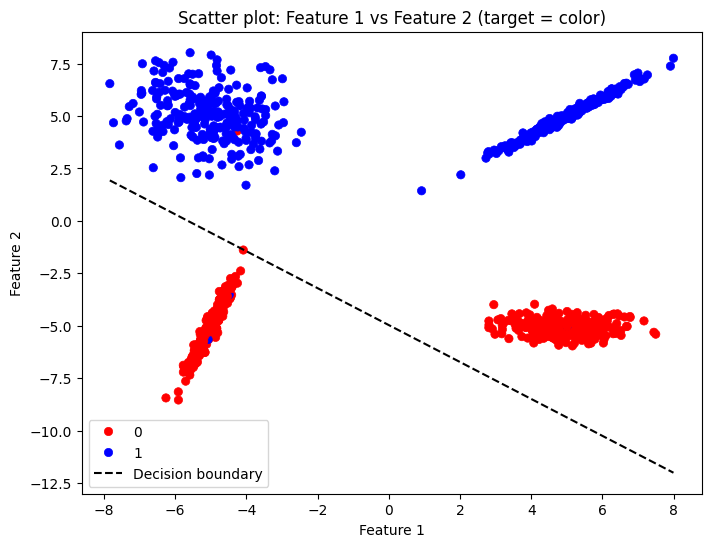

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(8, 6))
sns.scatterplot(
    data = df,
    x = "feature_1",
    y = "feature_2",
    hue = "target", # class represented by color
    palette =["red","blue"], #class 0 → red, class 1 → blue    alpha = 0.7, #lign transparency to see overlap
    edgecolor = None
)
plt.title("Scatter plot: Feature 1 vs Feature 2 (target = color)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title = "Target class", labels =["0" ,"1"])

x1_line = np.linspace(df["feature_1"].min(), df["feature_1"].max(), 100)
x2_line = -(intercept + coef[0] * x1_line) / coef[1]
plt.plot(x1_line, x2_line, 'k--', label='Decision boundary')
plt.legend()

plt.show()

In [18]:
perceptron_trick(X,y)

(np.float64(-0.25), array([-0.4041974 ,  2.69255882]))

# **Perceptron Trick With Sigmoid Function**

In [19]:
def sigmoid(z):
    return 1/(1+ np.exp(-z))

def perceptron_trick_with_sigmoid (X, y, lr=.25, epochs = 3500):

    X= np.insert(X, 0, 1, axis=1)
    weights = [1 for i in range(X.shape[1])]

    for i in range(epochs):
        j = np.random.randint(0, X.shape[0])
        y_hat = sigmoid(np.dot(X[j], weights))
        #print(y_hat, " ::: ", y[j], " ::: ", weights, " ::: ", end="")
        weights = weights + lr *(y[j]-y_hat)*X[j]
        #print(weights, " ::: ",lr *(y[j]-y_hat)*X[j])


    return weights [0],  weights [1:]

In [20]:
intercept, coef=perceptron_trick_with_sigmoid(np.array(X), np.array(y))

In [21]:
print(intercept)
print(coef)

1.735513990788097
[0.31739771 1.99452062]


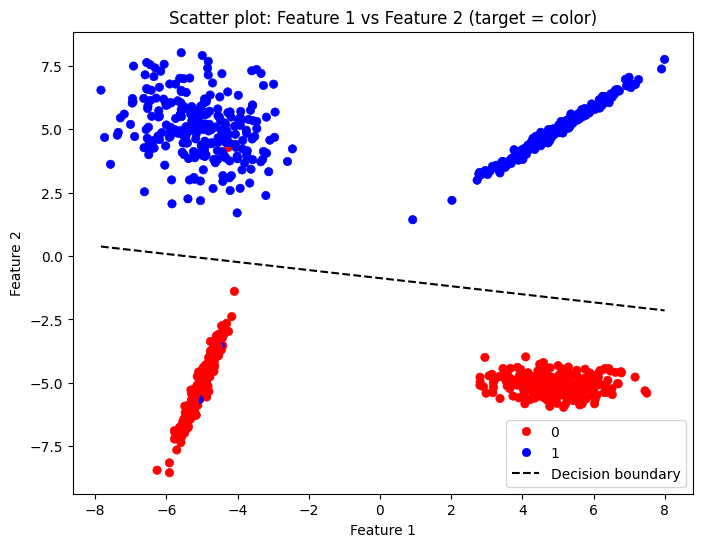

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize =(8, 6))
sns.scatterplot(
    data = df,
    x = "feature_1",
    y = "feature_2",
    hue = "target", # class represented by color
    palette =["red","blue"], #class 0 → red, class 1 → blue    alpha = 0.7, #lign transparency to see overlap
    edgecolor = None
)
plt.title("Scatter plot: Feature 1 vs Feature 2 (target = color)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title = "Target class", labels =["0" ,"1"])

x1_line = np.linspace(df["feature_1"].min(), df["feature_1"].max(), 100)
x2_line = -(intercept + coef[0] * x1_line) / coef[1]
plt.plot(x1_line, x2_line, 'k--', label='Decision boundary')
plt.legend()

plt.show()